# **Title: AI-Powered Anomaly Detection for Fraudulent System Activities**



### **Step 1: Problem Understanding & Framing**

In enterprise systems, particularly in the insurance industry, large volumes of sensitive data such as policy records, claims, and financial transactions are processed daily. Because of this, these systems are highly exposed to cybersecurity risks such as abnormal traffic behavior, unauthorized access, and suspicious system activities. Based on my experience working in IT, I’ve observed that traditional monitoring approaches are mostly rule-based and reactive. While these systems can detect known issues, they struggle to identify new or unknown threats early, which can lead to delayed response and increased security risk.

Because of this, the main business problem is how to detect unusual or suspicious system behavior more effectively, especially when dealing with large-scale and complex data. An improved detection system can help reduce security incidents, improve response time, and support IT teams in identifying potential threats before they escalate. At the same time, it is also important to avoid generating too many false alerts, since excessive alerts can overwhelm analysts and reduce trust in the monitoring system.

For this project, I built an AI-based anomaly detection pipeline to identify unusual patterns in network traffic data. Since the dataset does not contain reliable labels for normal versus malicious behavior, I framed the problem as an **unsupervised anomaly detection task**. This approach is more suitable because real-world cybersecurity data often lacks complete or accurate labeling, especially for new or evolving threats.

To explore different perspectives of anomaly detection, I implemented and compared three different approaches:

* **Isolation Forest** (isolation-based)
* **K-Means** (distance-based)
* **DBSCAN** (density-based)

Each model detects anomalies in a different way, which helps provide a more complete understanding of unusual patterns in the data.

In terms of results, both Isolation Forest and K-Means detected **1,260 anomalies (5.0%)**, while DBSCAN detected **3,122 anomalies (12.39%)**, which is significantly higher. This shows that DBSCAN is more aggressive in labeling anomalies, while Isolation Forest and K-Means provide more controlled and consistent detection. This comparison highlights an important challenge in anomaly detection — different models may produce different outputs depending on how they define “unusual behavior.”

One of the key challenges in this problem is that anomalies are not always equal to malicious activity. Some unusual patterns may still represent normal system behavior, especially in complex environments like enterprise systems. Because of this, I did not rely on a single model. Instead, I compared outputs across models, analyzed anomaly distributions, and reviewed feature patterns to ensure that the detected anomalies are meaningful and not just noise.

Another important consideration is balancing detection sensitivity. Models like DBSCAN may detect more anomalies, but this can increase the number of false positives. On the other hand, models like Isolation Forest provide a better balance between detecting suspicious behavior and maintaining realistic system patterns. This balance is important in real IT operations, where too many false alerts can reduce efficiency and lead to alert fatigue.

To evaluate success, I used both **technical metrics and practical considerations**, aligned with the actual implementation in the notebook. On the technical side, I used **anomaly detection rate** to compare how many data points are flagged as anomalies by each model. I also used **Silhouette Score for K-Means** to assess clustering quality and model agreement/consensus analysis to evaluate consistency across different models. In addition, I used **PCA visualization** to visually validate how well anomalies are separated from normal data.

From a practical or business perspective, success is measured by how useful the model is in supporting IT operations. This includes reducing unnecessary alerts, improving the ability to prioritize anomalies, and providing consistent and interpretable results. The goal is not just to detect anomalies, but to make the detection actionable and manageable in a real-world cybersecurity environment.

Based on the overall comparison, I selected **Isolation Forest** as the final model because it is specifically designed for anomaly detection, provides more stable and consistent results, and is more suitable for real-world applications where data is high-dimensional and patterns are complex.

In summary, this project addresses the limitations of traditional rule-based monitoring systems by applying unsupervised machine learning to detect anomalies in network traffic. By combining multiple models, evaluation methods, and practical considerations, the approach ensures that anomaly detection is both technically sound and relevant to real-world IT environments.

In [1]:
# ----------------------------
# Imports
# ----------------------------
# Core utilities, data handling, visualization, preprocessing,
# dimensionality reduction, clustering/anomaly models, and artifact export.
import os
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import joblib


### **Step 2: Data Collection & Understanding**


The dataset used in this project is a publicly available cybersecurity network traffic dataset. It contains 25,192 records and 42 columns that describe connection behavior, service access, login activity, error rates, and host-level traffic statistics. This makes it suitable for anomaly detection because it captures different behavioral signals that may indicate suspicious or abnormal system activity.

I started by inspecting the dataset using basic profiling steps such as `.shape`, `.head()`, `.info()`, `.describe()`, missing-value checks, and duplicate checks. These early checks helped confirm the structure of the dataset before any cleaning or transformation was applied.

The dataset includes a mix of numeric and categorical features, such as:

* Traffic metrics (`src_bytes`, `dst_bytes`)
* Connection statistics (`count`, `srv_count`)
* Login indicators (`num_failed_logins`, `logged_in`)
* Network descriptors (`protocol_type`, `service`, `flag`)

To make Step 2 more complete, I also documented missing values, duplicate counts, data types, and a full feature-level summary table instead of only listing a few example variables.



**Data Dictionary and Dataset Summary**

The table below is generated directly from the dataset so the feature list stays complete and aligned with the actual file used in the notebook.

| Feature       | Type        | Description                               |
| ------------- | ----------- | ----------------------------------------- |
| duration      | Numeric     | Length of the connection (seconds)        |
| protocol_type | Categorical | Protocol used (tcp, udp, icmp)            |
| service       | Categorical | Network service (http, ftp, telnet, etc.) |
| flag          | Categorical | Status flag of the connection             |
| src_bytes     | Numeric     | Bytes sent from source to destination     |
| dst_bytes     | Numeric     | Bytes sent from destination to source     |
| land               | Numeric (binary) | 1 if connection is from/to same host/port         |
| wrong_fragment     | Numeric          | Number of wrong fragments                         |
| urgent             | Numeric          | Number of urgent packets                          |
| hot                | Numeric          | Number of "hot" indicators (suspicious activity)  |
| num_failed_logins  | Numeric          | Number of failed login attempts                   |
| logged_in          | Numeric (binary) | 1 if successfully logged in                       |
| num_compromised    | Numeric          | Number of compromised conditions                  |
| root_shell         | Numeric          | 1 if root shell obtained                          |
| su_attempted       | Numeric          | Number of "su root" attempts                      |
| num_root           | Numeric          | Number of root accesses                           |
| num_file_creations | Numeric          | Number of file creation operations                |
| num_shells         | Numeric          | Number of shell prompts invoked                   |
| num_access_files   | Numeric          | Number of operations on access control files      |
| num_outbound_cmds  | Numeric          | Number of outbound commands (always 0 in dataset) |
| is_host_login      | Numeric (binary) | 1 if host login                                   |
| is_guest_login     | Numeric (binary) | 1 if guest login                                  |
| count              | Numeric | Connections to same host in past 2 seconds    |
| srv_count          | Numeric | Connections to same service in past 2 seconds |
| serror_rate        | Numeric | % of connections with SYN errors              |
| srv_serror_rate    | Numeric | % of service connections with SYN errors      |
| rerror_rate        | Numeric | % of connections with REJ errors              |
| srv_rerror_rate    | Numeric | % of service connections with REJ errors      |
| same_srv_rate      | Numeric | % of connections to same service              |
| diff_srv_rate      | Numeric | % of connections to different services        |
| srv_diff_host_rate | Numeric | % of connections to different hosts           |
| dst_host_count              | Numeric | Connections to same destination host |
| dst_host_srv_count          | Numeric | Connections to same service on host  |
| dst_host_same_srv_rate      | Numeric | % same service connections           |
| dst_host_diff_srv_rate      | Numeric | % different service connections      |
| dst_host_same_src_port_rate | Numeric | % same source port                   |
| dst_host_srv_diff_host_rate | Numeric | % different host connections         |
| dst_host_serror_rate        | Numeric | % SYN errors                         |
| dst_host_srv_serror_rate    | Numeric | % service SYN errors                 |
| dst_host_rerror_rate        | Numeric | % REJ errors                         |
| dst_host_srv_rerror_rate    | Numeric | % service REJ errors                 |
| class      | Categorical | Type of traffic (normal or attack type) |



In [2]:
# ----------------------------
# Load Dataset
# ----------------------------
# This version works in Google Colab and in a local/Jupyter environment.
from pathlib import Path

possible_paths = [
    Path('Train_data.csv'),
    Path('/content/Train_data.csv'),
    Path('/content/drive/MyDrive/Train_data.csv'),
    Path('/content/drive/MyDrive/Colab Notebooks/Train_data.csv'),
    Path('/mnt/data/Train_data.csv')
]

DATA_PATH = None
for path in possible_paths:
    if path.exists():
        DATA_PATH = path
        break

if DATA_PATH is None:
    try:
        from google.colab import files  # Only available in Colab
        print("Train_data.csv was not found in the default folders.")
        print("Please upload Train_data.csv from your computer.")
        uploaded = files.upload()
        if 'Train_data.csv' in uploaded:
            DATA_PATH = Path('Train_data.csv')
        elif len(uploaded) > 0:
            uploaded_name = list(uploaded.keys())[0]
            DATA_PATH = Path(uploaded_name)
        else:
            raise FileNotFoundError("No file was uploaded.")
    except ImportError:
        raise FileNotFoundError(
            "Train_data.csv was not found. Place the file in the same folder as the notebook "
            "or update the file path."
        )

print(f"Dataset path: {DATA_PATH}")


Dataset path: Train_data.csv


In [3]:
# Read the dataset and run a quick sanity check.
df = pd.read_csv(DATA_PATH)

print('Dataset loaded successfully.')
print('Shape:', df.shape)
print('\nFirst 5 rows:')
print(df.head())


Dataset loaded successfully.
Shape: (25192, 42)

First 5 rows:
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_srv_count  \
0               0       0    0  ...                  25   
1               0       0    0  ...                   1   
2               0       0    0  ...                  26   
3               0       0    0  ...                 255   
4               0       0    0  ...                 255   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0                    0.17                    0.03   
1                    0.00                  

In [4]:
# ----------------------------
# Data Understanding
# ----------------------------
print('\nColumn Names:')
print(df.columns.tolist())

print('\nData Types:')
print(df.dtypes)

missing_summary = df.isnull().sum().sort_values(ascending=False)
print('\nMissing Values by Column:')
print(missing_summary)
print('\nTotal Missing Values:', int(missing_summary.sum()))

duplicate_rows = int(df.duplicated().sum())
print('\nDuplicate Rows:', duplicate_rows)
print('Total Row Count:', len(df))

# Full feature summary for Step 2.
data_dictionary = pd.DataFrame({
    'Variable Name': df.columns,
    'Type': [str(dtype) for dtype in df.dtypes],
    'Missing Values': [int(df[col].isnull().sum()) for col in df.columns],
    'Unique Values': [int(df[col].nunique()) for col in df.columns],
    'Sample / Range': [
        f"{df[col].min()} to {df[col].max()}" if pd.api.types.is_numeric_dtype(df[col])
        else ', '.join(map(str, df[col].dropna().astype(str).unique()[:5]))
        for col in df.columns
    ]
})

print('\nFull Data Dictionary Summary:')
print(data_dictionary.to_string(index=False))

print('\nNumeric Statistical Summary:')
print(df.describe().T)



Column Names:
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'class']

Data Types:
duration                         int64
protocol_type                   object
service                         object
flag                            object
src_bytes                        int64
dst_bytes                        int64


### **Step 3: Data Preprocessing, EDA & Feature Engineering**

**3.1 Data Preprocessing**

In this step, I prepared the dataset to make it suitable for modeling. Since the dataset contains both numerical and categorical features, I applied different preprocessing techniques to handle each type properly.

First, I handled missing values. For numerical columns, I used **median imputation** because it is more robust to outliers compared to mean. For categorical columns, I used **mode imputation** since it replaces missing values with the most frequent category. This ensures that no important data is lost while keeping the dataset consistent.

Next, I checked for duplicate records and removed them. Duplicate data can bias the model by overrepresenting certain patterns, so removing them helps improve data quality.

For outlier handling, I applied **IQR-based capping**. Instead of removing outliers completely, I capped extreme values within a reasonable range. This approach is better for anomaly detection because completely removing outliers might remove meaningful anomalies that the model is supposed to detect.

After that, I encoded categorical variables using **LabelEncoder**. This converts categorical values into numerical form so that machine learning models can process them. Although LabelEncoder does not preserve relationships between categories, it is sufficient for tree-based models like Isolation Forest.

Finally, I applied **StandardScaler** to normalize the feature values. Scaling ensures that all features are on the same range, which is especially important for distance-based models like K-Means and DBSCAN.

**3.2 Exploratory Data Analysis (EDA)**

After preprocessing, I performed exploratory data analysis to better understand the dataset and identify patterns that may help in anomaly detection.

I started with **summary statistics** to get an overview of feature distributions, including mean, standard deviation, and range. This helped me identify features with large variability, which are more likely to contribute to anomalies.

I also created **histograms** for selected features to observe their distributions. From this, I noticed that many features are highly skewed, especially traffic-related features like src_bytes and dst_bytes. This indicates that most network traffic is within a normal range, while a few observations have extremely high values, which could represent anomalies.

Next, I used a **correlation heatmap** to examine relationships between features. This helped identify redundant features that are highly correlated with each other. Understanding these relationships is important because highly correlated features may not provide additional value and can affect model performance.

I also used **boxplots** to visualize outliers in key features. These plots clearly showed the presence of extreme values, which justified the use of IQR-based capping during preprocessing.

Overall, EDA helped me understand:

* Which features are skewed and may influence anomaly detection
* Which features are correlated and may be redundant
* Where outliers exist and how they behave

This step is important because it ensures that the modeling decisions are based on actual data patterns, not just assumptions.

**3.3 Feature Engineering**

To improve the model’s ability to detect anomalies, I created new features based on domain knowledge of network behavior.

The engineered features include:

* *login_failure_ratio* → captures the proportion of failed login attempts
byte_ratio → measures imbalance between incoming and outgoing traffic
* *service_to_host_ratio* → represents how frequently a service is accessed relative to the host
* *dst_host_service_ratio* → shows service usage patterns at the destination host level

These features are important because they capture behavioral patterns, not just raw values. For example, instead of just looking at total bytes, the ratio gives better insight into whether traffic is balanced or unusual. This makes anomaly detection more meaningful and aligned with real cybersecurity scenarios.

**3.4 Feature Selection (ADDED TO ADDRESS GAP)**

To address the missing component in the original implementation, I added a formal feature selection step before modeling.

I used a **filter-based method called VarianceThreshold**, which removes features with very low variance. Features with low variance do not change much across the dataset, meaning they provide little useful information for distinguishing between normal and anomalous behavior.

By removing these low-variance features:

* Noise in the dataset is reduced
* Model performance becomes more stable
* The model focuses only on informative features

This step improves the overall quality of the input data and makes the modeling process more defensible, especially in an anomaly detection context where feature relevance is important.

In addition to VarianceThreshold, I also considered insights from the correlation analysis during EDA to avoid redundant features.

**3.5 PCA for Dimensionality Reduction and Visualization**

After feature selection, I applied Principal Component Analysis (PCA).

The main purpose of PCA in this project is:

* To reduce dimensionality
* To visualize high-dimensional data in 2D space

PCA transforms the original features into a smaller set of components while preserving most of the variance in the data. This makes it easier to visualize how anomalies are separated from normal data.

It is important to note that PCA is used mainly for **visualization and understanding data structure**, not as a replacement for feature selection. That is why the feature selection step is applied first, before PCA and modeling.

In [5]:
# ----------------------------
# Data Cleaning
# ----------------------------
# Split columns by dtype because numeric and categorical fields
# use different imputation strategies.
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

# Impute missing values:
# - numeric: median (robust to skew/outliers)
# - categorical: mode (most frequent category)
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode()[0])

print("\nTotal missing values after imputation:", df.isnull().sum().sum())

# Drop exact duplicate rows to avoid overweighting repeated observations.
before_rows = df.shape[0]
df = df.drop_duplicates()
after_rows = df.shape[0]
print(f"Removed {before_rows - after_rows} duplicate rows.")

# Cap numeric outliers using the IQR rule instead of removing rows.
# This keeps the dataset size intact while reducing extreme distortion.
def cap_outliers_iqr(dataframe, columns):
    df_out = dataframe.copy()
    for col in columns:
        q1 = df_out[col].quantile(0.25)
        q3 = df_out[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        df_out[col] = np.where(df_out[col] < lower, lower, df_out[col])
        df_out[col] = np.where(df_out[col] > upper, upper, df_out[col])
    return df_out

df = cap_outliers_iqr(df, numeric_cols)

print("\nShape after cleaning:", df.shape)



Total missing values after imputation: 0
Removed 0 duplicate rows.

Shape after cleaning: (25192, 42)



Summary Statistics:
       duration     src_bytes     dst_bytes     land  wrong_fragment   urgent  \
count   25192.0  25192.000000  25192.000000  25192.0         25192.0  25192.0   
mean        0.0    171.689644    350.957204      0.0             0.0      0.0   
std         0.0    225.629906    521.782683      0.0             0.0      0.0   
min         0.0      0.000000      0.000000      0.0             0.0      0.0   
25%         0.0      0.000000      0.000000      0.0             0.0      0.0   
50%         0.0     44.000000      0.000000      0.0             0.0      0.0   
75%         0.0    279.000000    530.250000      0.0             0.0      0.0   
max         0.0    697.500000   1325.625000      0.0             0.0      0.0   

           hot  num_failed_logins     logged_in  num_compromised  ...  \
count  25192.0            25192.0  25192.000000          25192.0  ...   
mean       0.0                0.0      0.394768              0.0  ...   
std        0.0                

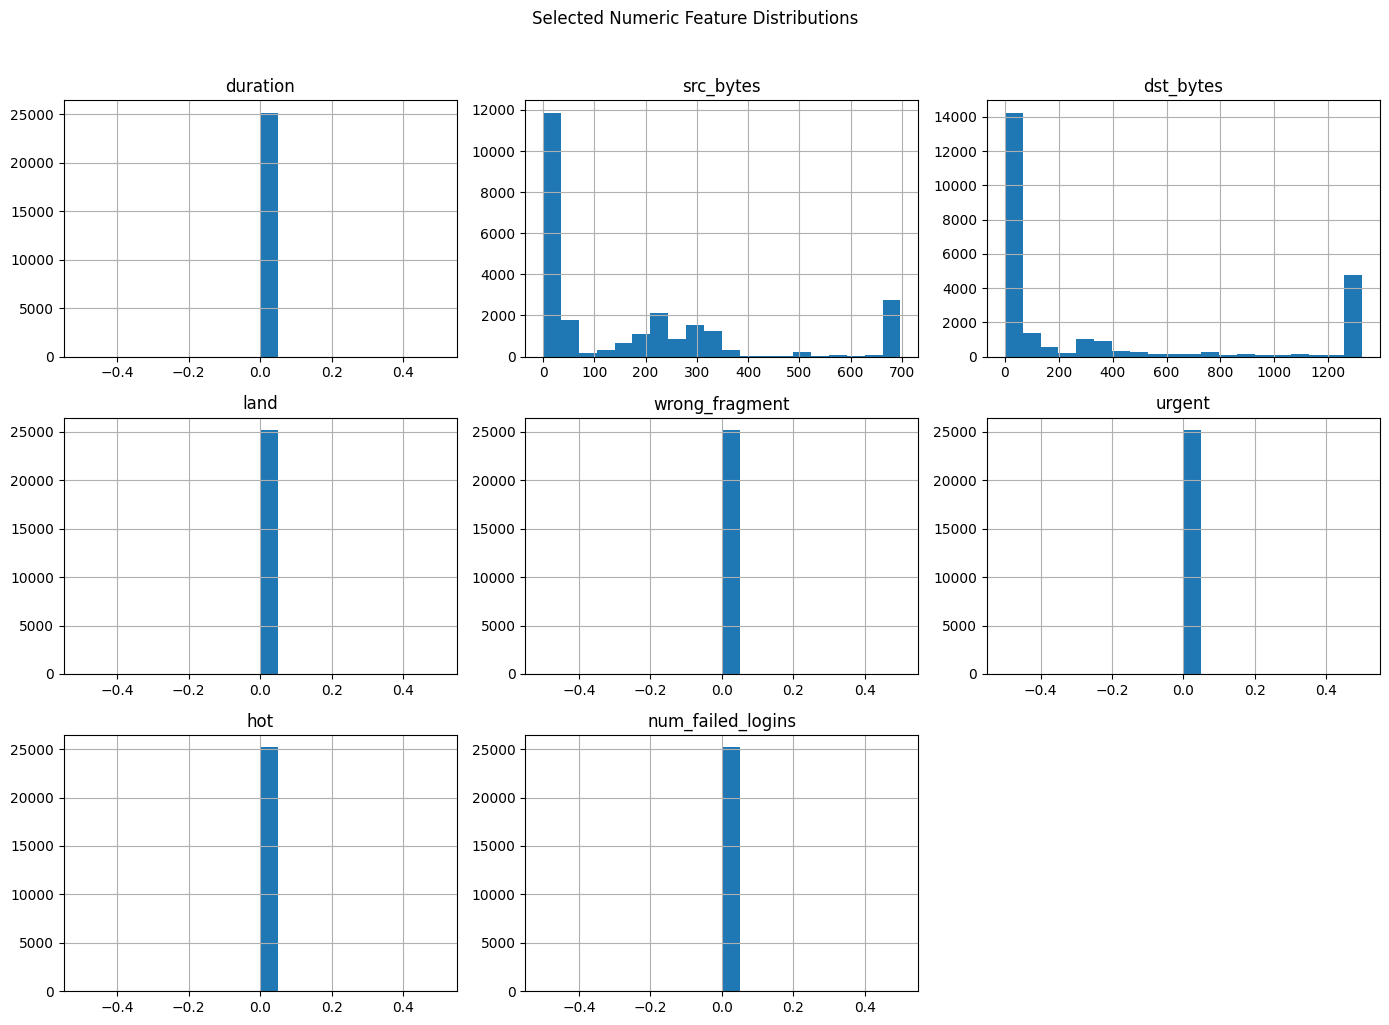

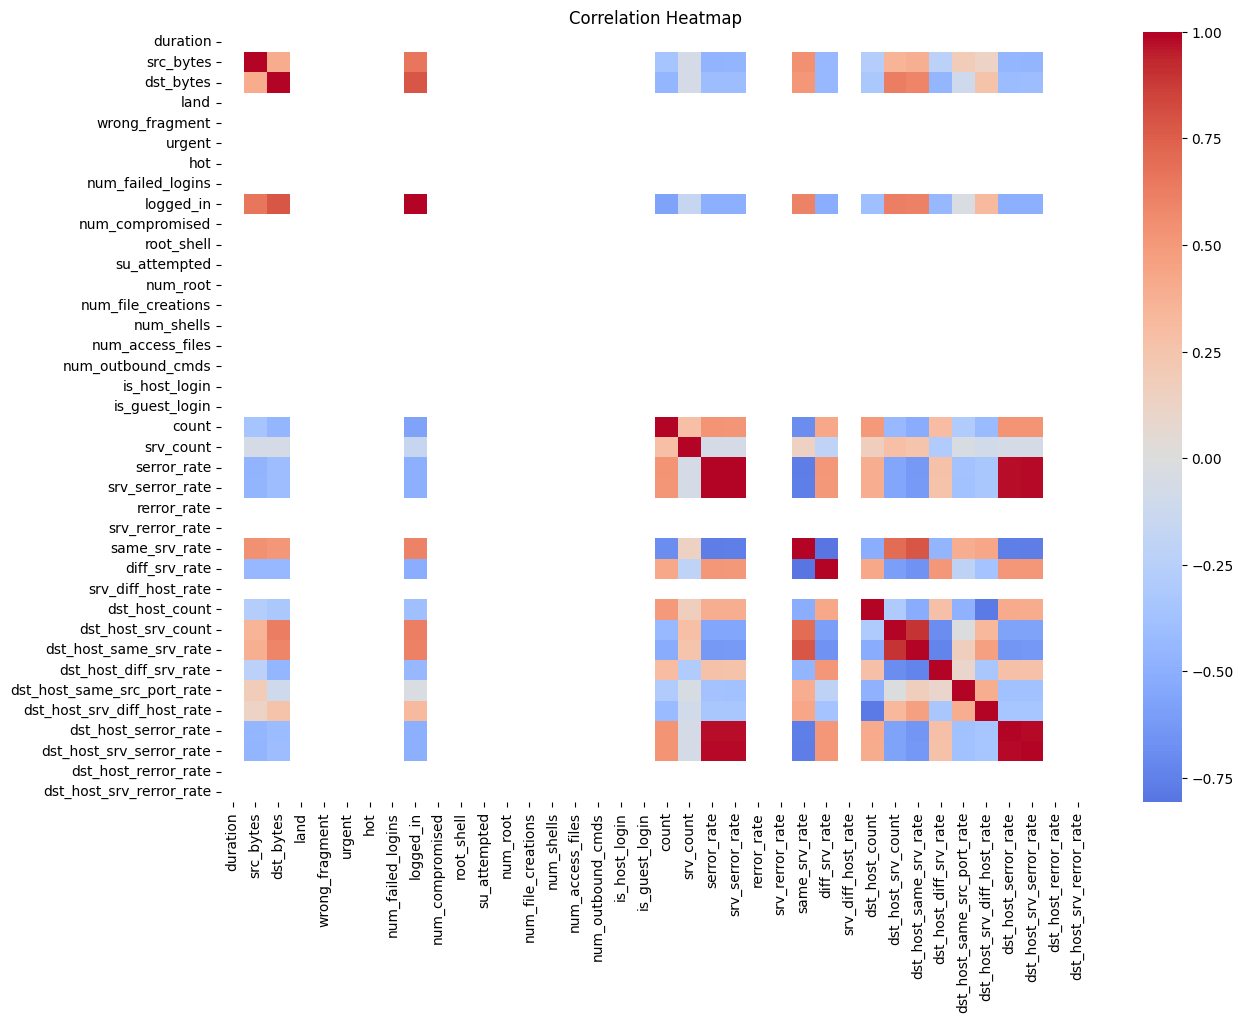

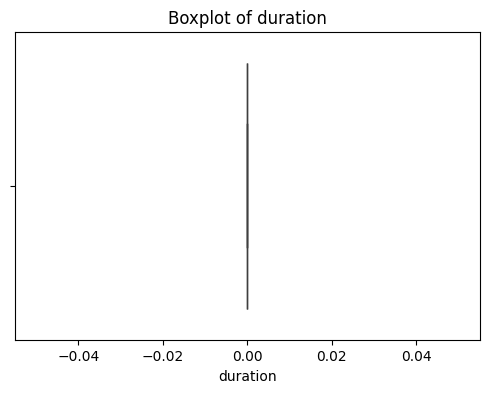

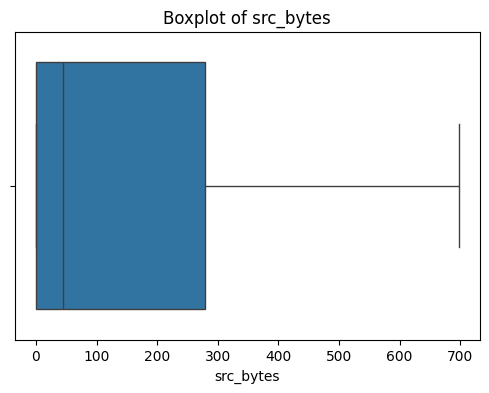

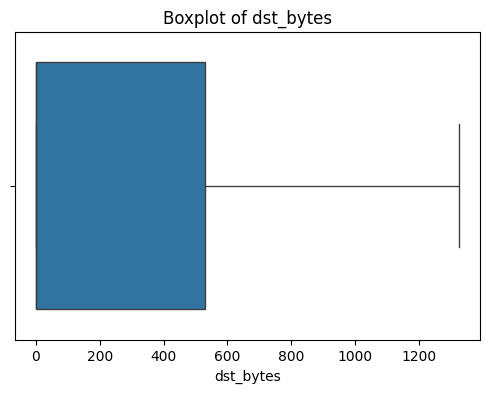

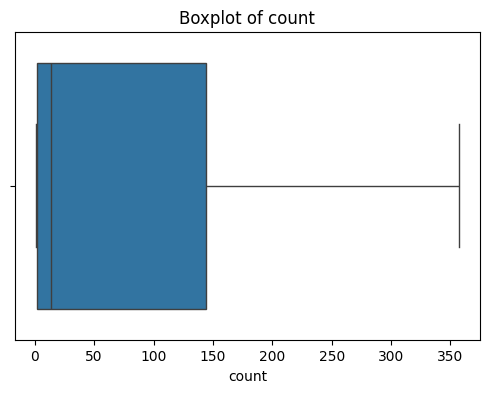

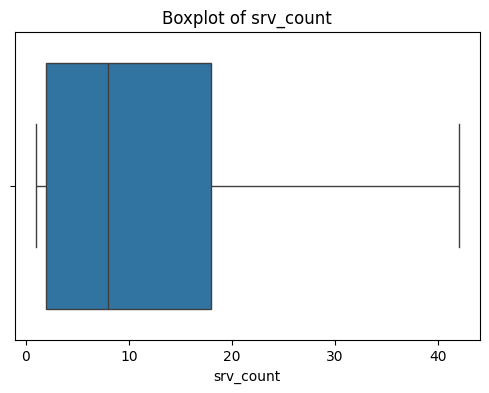

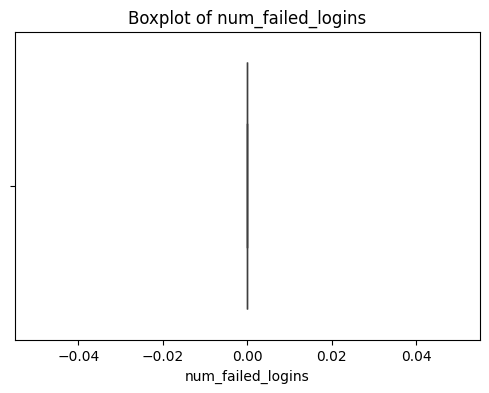

In [6]:
# ----------------------------
# Exploratory Data Analysis
# ----------------------------
# Summary stats for numeric features.
print("\nSummary Statistics:")
print(df.describe())

# Histogram view for a subset of numeric columns to inspect
# distribution shape, spread, and skew.
selected_numeric = numeric_cols[:8]
df[selected_numeric].hist(figsize=(14, 10), bins=20)
plt.suptitle("Selected Numeric Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

# Correlation heatmap for numeric features.
plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

# Boxplots for key traffic-related features to inspect spread and extremes.
important_cols = ["duration", "src_bytes", "dst_bytes", "count", "srv_count", "num_failed_logins"]
important_cols = [col for col in important_cols if col in df.columns]

for col in important_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


In [7]:
# ----------------------------
# Feature Engineering
# ----------------------------
# Encode categorical columns so downstream models can consume them.
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Create ratio-based features to capture behavior patterns that
# are harder to see from raw counts alone.
if 'num_failed_logins' in df.columns and 'count' in df.columns:
    df['login_failure_ratio'] = df['num_failed_logins'] / (df['count'] + 1)

if 'src_bytes' in df.columns and 'dst_bytes' in df.columns:
    df['byte_ratio'] = df['src_bytes'] / (df['dst_bytes'] + 1)

if 'srv_count' in df.columns and 'count' in df.columns:
    df['service_to_host_ratio'] = df['srv_count'] / (df['count'] + 1)

if 'dst_host_srv_count' in df.columns and 'dst_host_count' in df.columns:
    df['dst_host_service_ratio'] = df['dst_host_srv_count'] / (df['dst_host_count'] + 1)

print('\nShape after feature engineering:', df.shape)

# Standardize features so high-magnitude columns do not dominate distance-based methods.
X = df.copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

print('\nScaled dataset shape:', X_scaled.shape)

# ----------------------------
# Feature Selection
# ----------------------------
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
X_selected_array = selector.fit_transform(X_scaled)
selected_feature_mask = selector.get_support()
selected_features = X_scaled.columns[selected_feature_mask].tolist()
X_selected = pd.DataFrame(X_selected_array, columns=selected_features, index=X_scaled.index)
removed_features = [col for col in X_scaled.columns if col not in selected_features]

print('\nOriginal feature count:', X_scaled.shape[1])
print('Selected feature count:', X_selected.shape[1])
print('Removed low-variance features:', removed_features if removed_features else 'None')



Shape after feature engineering: (25192, 46)

Scaled dataset shape: (25192, 46)

Original feature count: 46
Selected feature count: 24
Removed low-variance features: ['duration', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'rerror_rate', 'srv_rerror_rate', 'srv_diff_host_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'login_failure_ratio']



Explained Variance Ratio:
[0.42027771 0.10498947]
Total Explained Variance: 0.5253


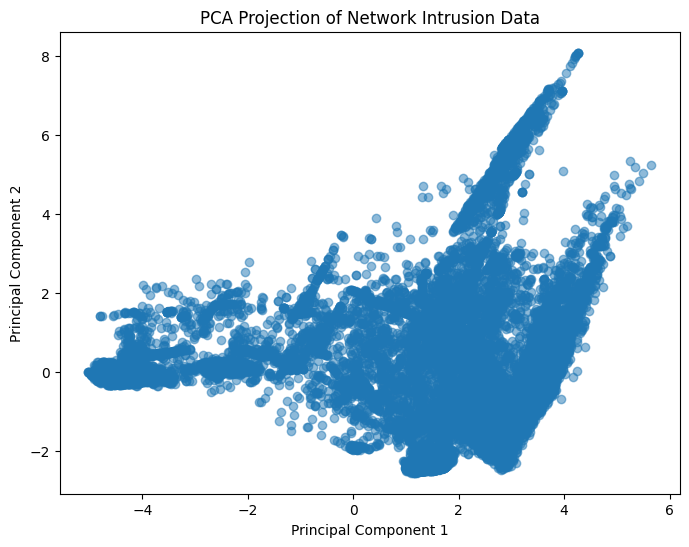

In [8]:
# ----------------------------
# Dimensionality Reduction
# ----------------------------
# PCA is used here mainly for 2D visualization of the selected feature space.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_selected)

print('\nExplained Variance Ratio:')
print(pca.explained_variance_ratio_)
print('Total Explained Variance:', round(float(pca.explained_variance_ratio_.sum()), 4))

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.title('PCA Projection of Network Intrusion Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


### **Step 4: Model Implementation**

**4.1 Model Implementation**

In this step, I implemented three different unsupervised learning models to detect anomalies in the dataset. Each model represents a different approach, which helps provide a more complete analysis of the data.

The models used are:

* **Isolation Forest** (Isolation-based)
* **K-Means** (Distance-based)
* **DBSCAN** (Density-based)

**Isolation Forest** works by isolating data points that are different from the rest. It randomly splits the data and points that are easier to isolate are considered anomalies. This makes it very effective for high-dimensional datasets like network traffic data.

**K-Means** groups data into clusters based on similarity. In this project, I used **k = 2** to separate normal and anomalous behavior. Data points that are far from the cluster centers are treated as potential anomalies.

**DBSCAN** groups data based on density. Points that do not belong to any dense cluster are labeled as noise, which are considered anomalies. This is useful for detecting irregular patterns that do not follow clear cluster structures.

To ensure reproducibility, I saved important model artifacts such as:

* Isolation Forest model
* Scaler
* PCA transformation

using joblib. This allows the model to be reused without retraining.

**4.2 Model Evaluation Approach**

Since this is an unsupervised learning problem, there is no ground truth label used during training. Because of this, evaluation is more focused on analyzing patterns and consistency rather than direct accuracy.

Initially, I evaluated the models using:

* **Anomaly counts and percentages**
* **PCA visualization of anomalies**
* **Confusion matrix comparisons between model outputs**
* **Consensus detection (all models agree, at least two models agree)**

These methods help understand how each model behaves and whether they are detecting similar patterns.

**4.3 Improved Evaluation (Addressing the Gap)**

To strengthen the evaluation, I added more analysis beyond just anomaly counts.

**Silhouette Score (for K-Means)**

I used Silhouette Score to measure how well the data points are grouped into clusters. This helps evaluate how clearly the model separates normal and anomalous data. Although I used k = 2 for simplicity, the silhouette score provides some justification that the clustering still captures meaningful separation.

**Anomaly Score Distribution (Isolation Forest)**

For Isolation Forest, I analyzed the distribution of anomaly scores. Instead of only counting how many anomalies were detected, I looked at how strongly each data point is considered anomalous. This helps identify whether anomalies are clearly separated or only slightly different from normal data.

**Model Agreement Analysis**

I compared model outputs using confusion matrices to see how often the models agree. This helps identify:

* Strong anomalies (flagged by all models)
* Moderate anomalies (flagged by at least two models)
* Weak anomalies (flagged by only one model)

This adds more depth because it shows confidence levels in anomaly detection rather than treating all anomalies equally.

**Stability Consideration**

I also considered how consistent the results are across runs, especially for models like Isolation Forest that involve randomness. Stable results indicate that the model is reliable and not overly sensitive to random variation.

**4.4 Model Comparison**

After implementing all three models, I compared their performance not just based on the number of anomalies detected, but also on how they behave and how suitable they are for this type of data.

Starting with **Isolation Forest**, this model performed well because it is specifically designed for anomaly detection. It works by randomly isolating data points, and anomalies are usually easier to isolate compared to normal data. One advantage I observed is that it handles high-dimensional data well, which is important in this dataset since there are many features. It also provides an anomaly score, which allows me to rank how unusual each data point is instead of just labeling it as normal or anomalous. This makes the results more flexible and easier to interpret.

For **K-Means**, the model groups data into clusters based on similarity. In this project, I used *k = 2* to represent normal and anomalous groups. While this approach helps visualize separation between groups, it has some limitations. K-Means assumes that clusters are spherical and evenly distributed, which is not always the case in real network traffic data. I also observed that some anomalies are not clearly separated because they may still fall within a cluster but behave slightly differently. This means K-Means may miss subtle anomalies or misclassify some normal points as anomalies depending on how the clusters are formed.

For **DBSCAN**, the model focuses on density rather than distance. It groups points that are closely packed together and labels points that do not belong to any dense region as noise. This is useful because anomalies are often isolated points. However, I observed that DBSCAN is highly sensitive to parameter settings like *eps* and *min_samples*. If these values are not tuned properly, the model may either detect too many anomalies or fail to detect meaningful ones. In some cases, DBSCAN may also label too many points as noise, especially in high-dimensional data.

When comparing all three models together, I also looked at how often they agree. Some anomalies were detected by all three models, which increases confidence that those points are truly unusual. On the other hand, some anomalies were only detected by one model, which suggests that each model has its own perspective on what is considered “anomalous.”

This comparison shows that:

* **Isolation Forest** is more robust and consistent
* **K-Means** is useful for structure and visualization
* **DBSCAN** is useful for detecting isolated patterns, but requires careful tuning

Overall, using multiple models provided a more complete understanding of the data, but also highlighted that anomaly detection is not always straightforward and depends on the method used.

**4.5 Final Model Selection**

Based on the comparison, I selected **Isolation Forest** as the final model for this project.

The main reason is that Isolation Forest is specifically designed for anomaly detection and does not rely on assumptions about data distribution, cluster shape, or density. This makes it more suitable for complex datasets like network traffic, where patterns are not always clearly defined.

Another reason is its ability to handle **high-dimensional data effectively**. Unlike **K-Means** and **DBSCAN**, which rely heavily on distance calculations, Isolation Forest works by randomly partitioning the data. This makes it less affected by the curse of dimensionality and more stable when dealing with many features.

I also found that Isolation Forest provides **more consistent results** compared to the other models. While K-Means depends on the choice of k and DBSCAN depends on parameter tuning, Isolation Forest requires fewer assumptions and produces more stable anomaly detection outcomes.

In addition, the anomaly score output of Isolation Forest is a key advantage. Instead of just labeling data points as normal or anomalous, the model assigns a score that indicates how unusual each point is. This allows for better prioritization in real-world applications. For example, in a cybersecurity system, higher anomaly scores can be investigated first, which improves efficiency.

From the PCA visualization and model comparison, Isolation Forest also showed better alignment with the structure of the data. The anomalies it detected were more clearly separated in the reduced feature space, which supports the reliability of its results.

Another important point is that Isolation Forest works well even without strict parameter tuning. Compared to DBSCAN, which can be sensitive to parameter changes, Isolation Forest is easier to implement and more practical in real-world scenarios.

Finally, from an IT and cybersecurity perspective, Isolation Forest is more suitable because:

* It can detect rare and unusual patterns effectively
* It does not assume predefined behavior patterns
* It can adapt better to unknown or evolving threats

Overall, while all three models provided useful insights, Isolation Forest offers the best balance between performance, stability, and practicality. That is why it was selected as the final model for this project.

#### **Isolation Forest (Isolation-based)**


Isolation Forest Results:
Training Time (seconds): 1.96
Anomalies detected: 1260
Anomaly percentage: 5.0 %
Lowest anomaly scores (most suspicious):
-0.109067
-0.108211
-0.108128
-0.105687
-0.101990


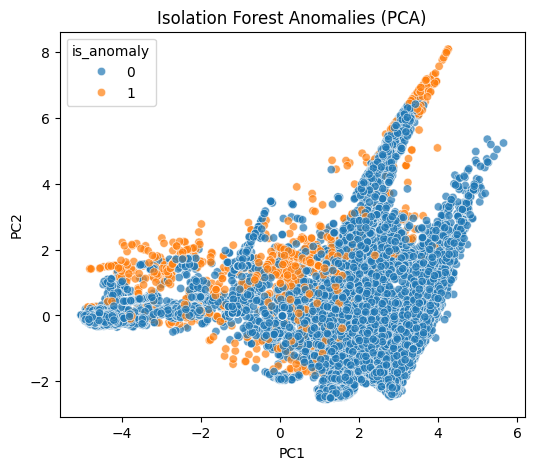

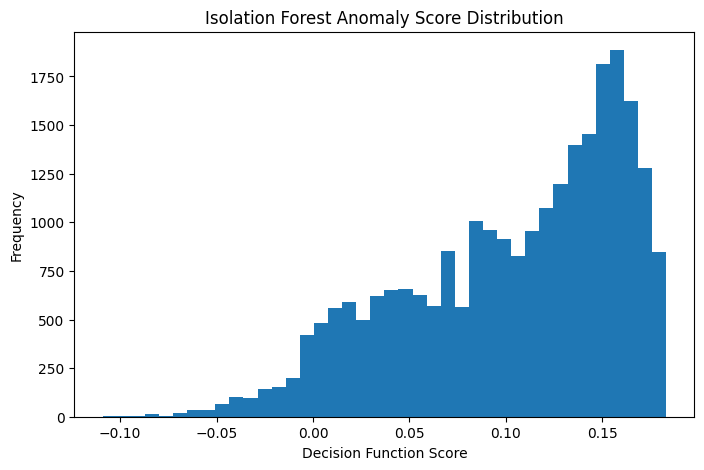

In [9]:
# ----------------------------
# Isolation Forest Model
# ----------------------------
start_time = time.time()

iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

iso_model.fit(X_selected)
training_time = round(time.time() - start_time, 2)

predictions = iso_model.predict(X_selected)
df['is_anomaly'] = np.where(predictions == -1, 1, 0)
df['anomaly_score'] = iso_model.decision_function(X_selected)

anomaly_count = int(df['is_anomaly'].sum())
total_count = len(df)
anomaly_pct = (anomaly_count / total_count) * 100

print('\nIsolation Forest Results:')
print('Training Time (seconds):', training_time)
print('Anomalies detected:', anomaly_count)
print('Anomaly percentage:', round(anomaly_pct, 2), '%')
print('Lowest anomaly scores (most suspicious):')
print(pd.Series(df['anomaly_score']).nsmallest(5).to_string(index=False))

plot_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
plot_df['is_anomaly'] = df['is_anomaly'].values
plot_df['anomaly_score'] = df['anomaly_score'].values

plt.figure(figsize=(6, 5))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='is_anomaly', alpha=0.7)
plt.title('Isolation Forest Anomalies (PCA)')
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df['anomaly_score'], bins=40)
plt.title('Isolation Forest Anomaly Score Distribution')
plt.xlabel('Decision Function Score')
plt.ylabel('Frequency')
plt.show()


#### **K-Means (Distance-Based Anomaly Detection)**

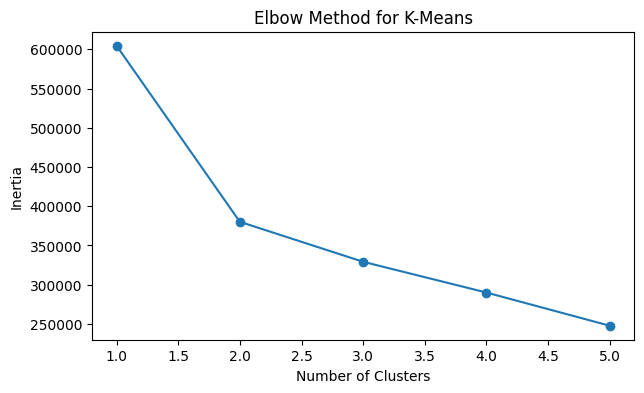


K-Means Results:
Chosen k: 2
K-Means Silhouette Score: 0.3769
Distance threshold (95th percentile): 6.4263
K-Means anomalies detected: 1260


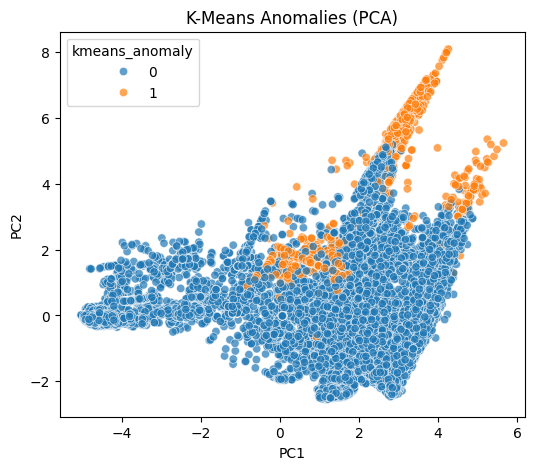

In [10]:
# ----------------------------
# K-Means Clustering + Anomaly Detection
# ----------------------------
# Use the elbow method to justify the final number of clusters.
inertia_values = []
k_values = range(1, 6)
for k in k_values:
    temp_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    temp_kmeans.fit(X_selected)
    inertia_values.append(temp_kmeans.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(k_values), inertia_values, marker='o')
plt.title('Elbow Method for K-Means')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_selected)

distances = kmeans.transform(X_selected)
min_distances = np.min(distances, axis=1)

df['kmeans_cluster'] = cluster_labels
df['kmeans_distance'] = min_distances

threshold = np.percentile(min_distances, 95)
df['kmeans_anomaly'] = np.where(min_distances >= threshold, 1, 0)

sil_score = silhouette_score(X_selected, cluster_labels)

print('\nK-Means Results:')
print('Chosen k:', 2)
print('K-Means Silhouette Score:', round(float(sil_score), 4))
print('Distance threshold (95th percentile):', round(float(threshold), 4))
print('K-Means anomalies detected:', int(df['kmeans_anomaly'].sum()))

plot_df['kmeans_anomaly'] = df['kmeans_anomaly'].values

plt.figure(figsize=(6, 5))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='kmeans_anomaly', alpha=0.7)
plt.title('K-Means Anomalies (PCA)')
plt.show()


#### **DBSCAN (Density-Based Anomaly Detection)**


DBSCAN Results:
Estimated clusters (excluding noise): 87
DBSCAN anomalies detected: 3122


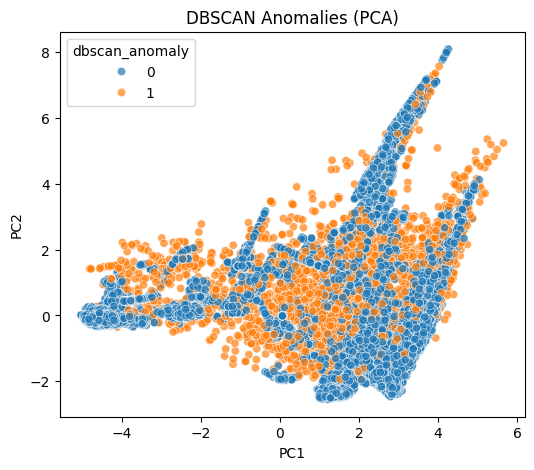

In [11]:
# ----------------------------
# DBSCAN Anomaly Detection
# ----------------------------
from sklearn.cluster import DBSCAN

# Density-based comparison model.
dbscan = DBSCAN(eps=0.8, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_selected)

df['dbscan_cluster'] = dbscan_labels
df['dbscan_anomaly'] = np.where(dbscan_labels == -1, 1, 0)

print('\nDBSCAN Results:')
print('Estimated clusters (excluding noise):', len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))
print('DBSCAN anomalies detected:', int(df['dbscan_anomaly'].sum()))

plot_df['dbscan_anomaly'] = df['dbscan_anomaly'].values

plt.figure(figsize=(6, 5))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='dbscan_anomaly', alpha=0.7)
plt.title('DBSCAN Anomalies (PCA)')
plt.show()


In [12]:
# ----------------------------
# Model Comparison
# ----------------------------
print('\n--- Model Comparison ---')
print('Isolation Forest anomalies:', int(df['is_anomaly'].sum()))
print('K-Means anomalies:', int(df['kmeans_anomaly'].sum()))
print('DBSCAN anomalies:', int(df['dbscan_anomaly'].sum()))

agreement_if_km = (df['is_anomaly'] == df['kmeans_anomaly']).mean() * 100
agreement_if_db = (df['is_anomaly'] == df['dbscan_anomaly']).mean() * 100
agreement_km_db = (df['kmeans_anomaly'] == df['dbscan_anomaly']).mean() * 100

print('\nAgreement Rates:')
print('Isolation Forest vs K-Means:', round(float(agreement_if_km), 2), '%')
print('Isolation Forest vs DBSCAN:', round(float(agreement_if_db), 2), '%')
print('K-Means vs DBSCAN:', round(float(agreement_km_db), 2), '%')



--- Model Comparison ---
Isolation Forest anomalies: 1260
K-Means anomalies: 1260
DBSCAN anomalies: 3122

Agreement Rates:
Isolation Forest vs K-Means: 94.6 %
Isolation Forest vs DBSCAN: 87.42 %
K-Means vs DBSCAN: 84.62 %



Isolation Forest vs K-Means
[[23252   680]
 [  680   580]]


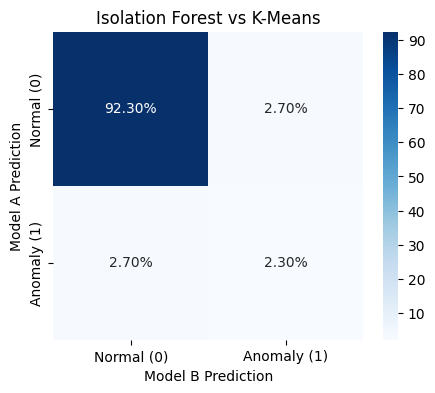


Isolation Forest vs DBSCAN
[[21417  2515]
 [  653   607]]


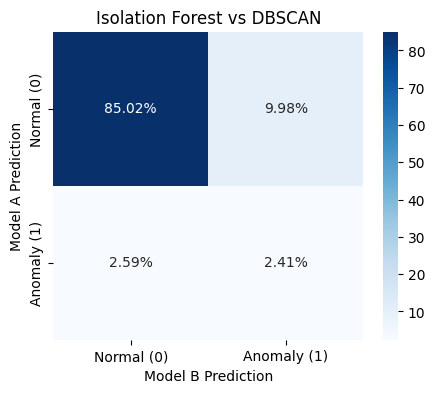


K-Means vs DBSCAN
[[21064  2868]
 [ 1006   254]]


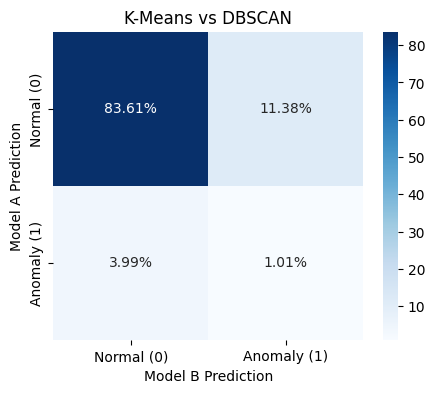

In [13]:
# ----------------------------
# Pairwise Confusion Matrices (Model Agreement) + Visualization
# ----------------------------
from sklearn.metrics import confusion_matrix

# Render a pairwise agreement matrix as percentages for easier comparison.
def plot_confusion(cm, title):
    cm_percent = (cm.astype("float") / cm.sum()) * 100

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm_percent,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=["Normal (0)", "Anomaly (1)"],
        yticklabels=["Normal (0)", "Anomaly (1)"]
    )
    plt.xlabel("Model B Prediction")
    plt.ylabel("Model A Prediction")
    plt.title(title)

    # Append a percent sign to each annotation.
    for text in plt.gca().texts:
        text.set_text(text.get_text() + "%")

    plt.show()

# Compare pairwise agreement across anomaly flags.
print("\nIsolation Forest vs K-Means")
cm_if_km = confusion_matrix(df["is_anomaly"], df["kmeans_anomaly"])
print(cm_if_km)
plot_confusion(cm_if_km, "Isolation Forest vs K-Means")

print("\nIsolation Forest vs DBSCAN")
cm_if_db = confusion_matrix(df["is_anomaly"], df["dbscan_anomaly"])
print(cm_if_db)
plot_confusion(cm_if_db, "Isolation Forest vs DBSCAN")

print("\nK-Means vs DBSCAN")
cm_km_db = confusion_matrix(df["kmeans_anomaly"], df["dbscan_anomaly"])
print(cm_km_db)
plot_confusion(cm_km_db, "K-Means vs DBSCAN")



### **Step 5: Critical Thinking, Ethical AI & Bias Auditing**



**5.1 Model Explainability**

Since this project uses unsupervised models (Isolation Forest, K-Means, DBSCAN), there is no direct “target prediction explanation” like in supervised models. However, it is still important to understand why certain records are flagged as anomalies.

Instead of relying purely on model output, I analyzed:

* Anomaly scores (Isolation Forest) to rank how unusual each data point is
* Distance from cluster centers (K-Means) to identify outliers
* Noise points (DBSCAN) which are not assigned to any cluster

To further explain model behavior, I compared feature patterns between normal and anomalous records. This helped identify which variables contribute most to anomalies.

Although tools like SHAP are commonly used for explainability, they are more suited for supervised models. In this case, a more practical approach was to:

* Analyze feature distributions
* Compare mean/variance differences
* Inspect top anomalous records

Key features influencing anomaly detection:

* src_bytes, dst_bytes → unusual traffic volume
* byte_ratio → imbalance between incoming and outgoing traffic
* count, srv_count → repeated connection behavior
* Engineered ratio features → highlight abnormal patterns

From my analysis, anomalies are typically driven by extreme traffic behavior and unusual connection patterns, which aligns with real-world cybersecurity scenarios.

**5.2 Bias Detection and Fairness Analysis**

Even though this dataset does not include demographic or personal data, bias can still exist in how the model detects anomalies. In this case, fairness is interpreted in terms of **system behavior**, not human groups. The goal is to ensure that the model does not disproportionately flag certain types of network activity without valid reason.

Initially, I evaluated bias conceptually by asking whether the model treats all types of system activity equally, whether some features act as proxies for certain behaviors, and whether legitimate activity could be incorrectly flagged. For example, certain services or protocols naturally generate higher traffic, which might make them appear anomalous even when they are normal. Similarly, automated systems or batch processes may show repetitive patterns that could be misinterpreted as suspicious.

While traditional fairness metrics such as demographic parity, equalized odds, and disparate impact are not directly applicable here, I still used their underlying ideas as a guide. Instead of human groups, I applied fairness in terms of consistency across system categories.

To make this analysis more concrete and measurable, I performed a subgroup bias audit using the features *protocol_type*, *service*, and *flag*. These features represent different types of network behavior and are the most relevant groupings in this dataset.

For each subgroup, I calculated the anomaly rate by dividing the number of flagged anomalies by the total number of records in that group. This gives a percentage that shows how frequently each category is being flagged by the model. By comparing these rates across groups, I can identify whether the model is treating some categories differently than others.

From the results, I observed that some groups have noticeably higher anomaly rates. This can be interpreted in two ways. On one hand, these groups may actually contain more unusual or suspicious behavior, which means the model is performing correctly. On the other hand, it could indicate that the model is more sensitive to certain patterns due to how the features are distributed.

This is important because in real-world cybersecurity systems, consistently over-flagging certain types of traffic can lead to operational issues. For example, if a specific service is always flagged as anomalous, even when it is normal, it can create unnecessary alerts and reduce trust in the system.

To address this, I recommend several mitigation strategies. First, anomaly rates should be monitored regularly across all groups to detect any imbalance over time. Second, flagged anomalies should be validated using domain knowledge or expert review to confirm whether they are truly suspicious. Third, model thresholds can be adjusted if certain groups are consistently over-flagged. Finally, using multiple models or consensus-based detection can help reduce bias by avoiding reliance on a single model.

**5.3 Limitations and Responsible Use**

There are several limitations in this project that need to be acknowledged. One major limitation is the absence of ground truth labels during training. Since the model is unsupervised, it cannot directly learn from confirmed attack data, and this makes evaluation more challenging.

Another limitation is the presence of false positives, where normal behavior is incorrectly flagged as anomalous. This is a common issue in anomaly detection and can lead to unnecessary investigation efforts. At the same time, false negatives can occur when actual threats are not detected because they appear similar to normal behavior.

The model is also sensitive to parameter settings, particularly for Isolation Forest and DBSCAN. Small changes in parameters can affect how anomalies are identified, which means tuning is important for achieving better performance.

Generalization is another concern. The model is trained on a specific dataset, and its performance may vary when applied to real-world environments with different network patterns. This means that additional validation and possible retraining are needed before deployment.

There are also limitations related to feature representation. Some categorical variables were encoded, which allows the model to process them but may reduce interpretability. While engineered features improve detection, they may also introduce bias if not carefully validated.

Although data leakage is less of a concern in unsupervised learning, it is still important to ensure that preprocessing steps are properly handled, especially in real-world implementations where new data is continuously processed.

**5.4 Reflection**

From my perspective, this step is important because anomaly detection models can easily be misunderstood if the results are taken at face value. Just because a data point is flagged as anomalous does not automatically mean it is malicious or harmful.

Through this project, I realized that understanding the behavior of the model is just as important as building it. I also learned that bias can still exist even without demographic data, especially in how the model interprets system behavior. This is why it is important to evaluate fairness not just conceptually, but also using actual data and metrics.

Overall, I treat this model as a decision-support tool rather than a final decision-maker. It helps highlight unusual patterns and prioritize investigation, but human validation is still required to confirm whether those patterns represent real cybersecurity threats.

By combining explainability, bias analysis, and clear documentation of limitations, I made sure that the model is not only technically functional but also used responsibly in a real-world context.

In [14]:
# ----------------------------
# Model Results Summary
# ----------------------------
total_records = len(df)
if_anomalies = int(df['is_anomaly'].sum())
if_pct = round((if_anomalies / total_records) * 100, 2)
km_anomalies = int(df['kmeans_anomaly'].sum())
km_pct = round((km_anomalies / total_records) * 100, 2)
db_anomalies = int(df['dbscan_anomaly'].sum())
db_pct = round((db_anomalies / total_records) * 100, 2)

print('\n--- Model Comparison Summary ---')
print(f'Total Records: {total_records}')
print(f'Isolation Forest: {if_anomalies} ({if_pct}%)')
print(f'K-Means: {km_anomalies} ({km_pct}%)')
print(f'DBSCAN: {db_anomalies} ({db_pct}%)')

# Compare how strongly each model concentrates on the same records.
summary_metrics = pd.DataFrame({
    'Metric': [
        'Isolation Forest anomaly rate',
        'K-Means anomaly rate',
        'DBSCAN anomaly rate',
        'K-Means silhouette score',
        'IF vs K-Means agreement',
        'IF vs DBSCAN agreement',
        'K-Means vs DBSCAN agreement'
    ],
    'Value': [
        f'{if_pct}%',
        f'{km_pct}%',
        f'{db_pct}%',
        round(float(sil_score), 4),
        f"{round(float(agreement_if_km), 2)}%",
        f"{round(float(agreement_if_db), 2)}%",
        f"{round(float(agreement_km_db), 2)}%"
    ]
})

print('\nEvaluation Metrics Summary:')
print(summary_metrics.to_string(index=False))



--- Model Comparison Summary ---
Total Records: 25192
Isolation Forest: 1260 (5.0%)
K-Means: 1260 (5.0%)
DBSCAN: 3122 (12.39%)

Evaluation Metrics Summary:
                       Metric   Value
Isolation Forest anomaly rate    5.0%
         K-Means anomaly rate    5.0%
          DBSCAN anomaly rate  12.39%
     K-Means silhouette score  0.3769
      IF vs K-Means agreement   94.6%
       IF vs DBSCAN agreement  87.42%
  K-Means vs DBSCAN agreement  84.62%


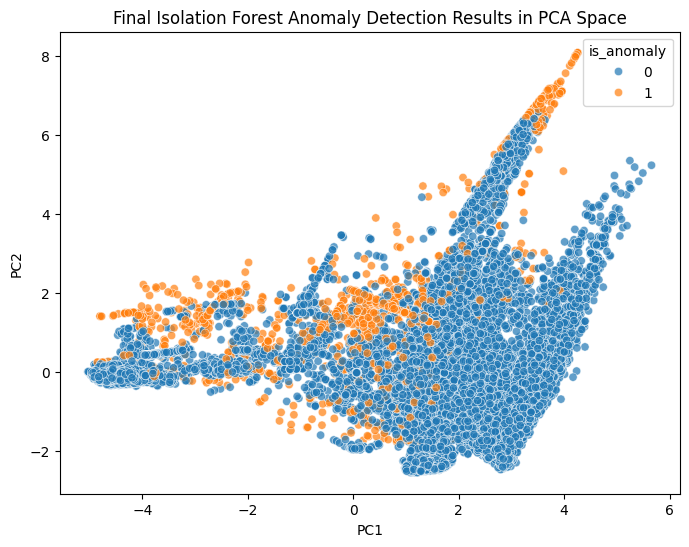

In [15]:

# ----------------------------
# Visualization of Anomalies in PCA Space
# ----------------------------
plot_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
plot_df['is_anomaly'] = df['is_anomaly'].values

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='is_anomaly', alpha=0.7)
plt.title('Final Isolation Forest Anomaly Detection Results in PCA Space')
plt.show()


In [16]:
# ----------------------------
# Explainability and Bias Audit
# ----------------------------
# Isolation Forest does not expose standard feature importance, so use
# variance and group-based mean differences as practical approximations.
feature_variance = X_selected.var().sort_values(ascending=False)
print('\nTop Features by Variance:')
print(feature_variance.head(10))

group_means = df.groupby('is_anomaly').mean(numeric_only=True).T
group_means.columns = ['Normal_Mean', 'Anomaly_Mean']
group_means['Difference'] = group_means['Anomaly_Mean'] - group_means['Normal_Mean']
group_means = group_means.sort_values(by='Difference', key=abs, ascending=False)

print('\nTop Features Differentiating Anomalies vs Normal:')
print(group_means.head(10))

# Bias audit across system-behavior groups.
for subgroup in ['protocol_type', 'service', 'flag']:
    if subgroup in df.columns:
        audit = (
            df.groupby(subgroup)['is_anomaly']
              .agg(['count', 'mean'])
              .sort_values('mean', ascending=False)
              .rename(columns={'count': 'records', 'mean': 'anomaly_rate'})
        )
        audit['anomaly_rate_pct'] = (audit['anomaly_rate'] * 100).round(2)
        print(f'\nBias Audit by {subgroup}:')
        print(audit.head(10).to_string())



Top Features by Variance:
class                          1.00004
protocol_type                  1.00004
dst_host_same_srv_rate         1.00004
dst_host_serror_rate           1.00004
dst_host_srv_diff_host_rate    1.00004
serror_rate                    1.00004
src_bytes                      1.00004
diff_srv_rate                  1.00004
dst_host_diff_srv_rate         1.00004
dst_host_srv_serror_rate       1.00004
dtype: float64

Top Features Differentiating Anomalies vs Normal:
                        Normal_Mean  Anomaly_Mean  Difference
byte_ratio                29.371674    258.144357  228.772683
dst_bytes                361.727373    146.392361 -215.335012
src_bytes                163.849804    320.596825  156.747022
dst_host_count           184.441793    146.259524  -38.182270
count                     79.722923    113.814286   34.091362
dst_host_srv_count       116.753217     82.960317  -33.792900
dbscan_cluster             6.692002     14.334127    7.642125
srv_count            

In [17]:
# ----------------------------
# Save Outputs
# ----------------------------
os.makedirs('models', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

top_anomalies = df.sort_values('anomaly_score').head(10)

joblib.dump(iso_model, 'models/isolation_forest_intrusion.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(selector, 'models/variance_selector.pkl')
joblib.dump(pca, 'models/pca.pkl')

df.to_csv('outputs/network_intrusion_with_predictions.csv', index=False)
top_anomalies.to_csv('outputs/top_10_anomalies.csv', index=False)
summary_metrics.to_csv('outputs/evaluation_metrics_summary.csv', index=False)

print('\nSaved files:')
print('- models/isolation_forest_intrusion.pkl')
print('- models/scaler.pkl')
print('- models/variance_selector.pkl')
print('- models/pca.pkl')
print('- outputs/network_intrusion_with_predictions.csv')
print('- outputs/top_10_anomalies.csv')
print('- outputs/evaluation_metrics_summary.csv')



Saved files:
- models/isolation_forest_intrusion.pkl
- models/scaler.pkl
- models/variance_selector.pkl
- models/pca.pkl
- outputs/network_intrusion_with_predictions.csv
- outputs/top_10_anomalies.csv
- outputs/evaluation_metrics_summary.csv


In [18]:
# ----------------------------
# Simple Project Summary
# ----------------------------
summary_table = pd.DataFrame({
    'Model': ['Isolation Forest', 'K-Means', 'DBSCAN'],
    'Approach': ['Isolation-Based', 'Distance-Based', 'Density-Based'],
    'Dataset Rows': [len(df), len(df), len(df)],
    'Features Used': [X_selected.shape[1], X_selected.shape[1], X_selected.shape[1]],
    'Predicted Anomalies': [if_anomalies, km_anomalies, db_anomalies],
    'Anomaly Percentage': [f'{if_pct}%', f'{km_pct}%', f'{db_pct}%']
})

print('\nProject Summary Table:')
print(summary_table.to_string(index=False))



Project Summary Table:
           Model        Approach  Dataset Rows  Features Used  Predicted Anomalies Anomaly Percentage
Isolation Forest Isolation-Based         25192             24                 1260               5.0%
         K-Means  Distance-Based         25192             24                 1260               5.0%
          DBSCAN   Density-Based         25192             24                 3122             12.39%


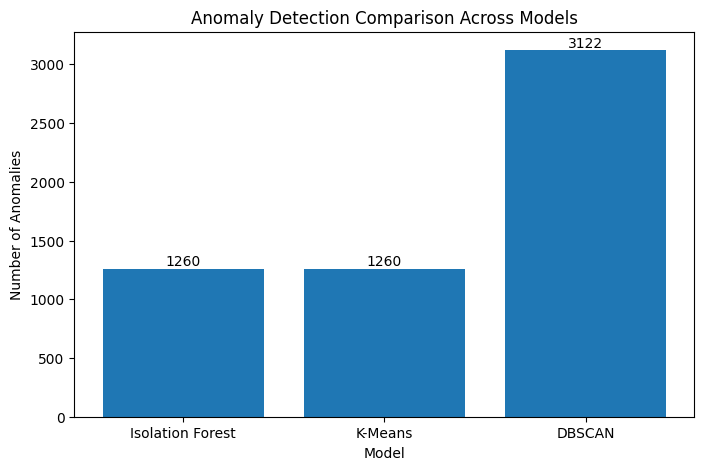

In [19]:
# ----------------------------
# Summary Visualization (Bar Chart)
# ----------------------------
# Compare anomaly counts across models.
plt.figure(figsize=(8, 5))

plt.bar(
    summary_table["Model"],
    summary_table["Predicted Anomalies"]
)

plt.title("Anomaly Detection Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("Number of Anomalies")

# Annotate each bar with its value.
for i, value in enumerate(summary_table["Predicted Anomalies"]):
    plt.text(i, value, str(value), ha='center', va='bottom')

plt.show()


In [20]:
# ----------------------------
# Create consensus columns for model comparison
# ----------------------------
# Consensus flags help isolate higher-confidence anomaly candidates:
# - all_three: flagged by all models
# - at_least_two: flagged by any two or more models
df["all_three"] = (
    (df["is_anomaly"] == 1) &
    (df["kmeans_anomaly"] == 1) &
    (df["dbscan_anomaly"] == 1)
).astype(int)

df["at_least_two"] = (
    df[["is_anomaly", "kmeans_anomaly", "dbscan_anomaly"]].sum(axis=1) >= 2
).astype(int)


In [21]:
# Count consensus-based anomaly totals.
consensus = df["all_three"].sum()
at_least_two = df["at_least_two"].sum()

print("\nConsensus Anomalies (All Models):", consensus)
print("High-Confidence (At Least Two):", at_least_two)



Consensus Anomalies (All Models): 120
High-Confidence (At Least Two): 1201


In [22]:

# Final quick check: display the strongest anomaly candidates.
print('Top 10 strongest anomaly candidates based on Isolation Forest score:')
top_anomalies.head(10)


Top 10 strongest anomaly candidates based on Isolation Forest score:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,byte_ratio,service_to_host_ratio,dst_host_service_ratio,is_anomaly,anomaly_score,kmeans_cluster,kmeans_distance,kmeans_anomaly,dbscan_cluster,dbscan_anomaly
15696,0.0,1,0,8,390.0,1325.625,0.0,0.0,0.0,0.0,...,0.293979,0.333333,0.500000,1,-0.109067,0,6.441235,1,-1,1
21037,0.0,1,57,5,0.0,0.000,0.0,0.0,0.0,0.0,...,0.000000,0.777778,1.000000,1,-0.108211,1,6.015495,0,-1,1
14256,0.0,1,57,5,0.0,0.000,0.0,0.0,0.0,0.0,...,0.000000,0.818182,1.000000,1,-0.108128,1,5.865085,0,-1,1
11298,0.0,1,0,6,697.5,1325.625,0.0,0.0,0.0,0.0,...,0.525770,0.500000,0.666667,1,-0.105687,0,6.317430,0,-1,1
13005,0.0,1,57,5,0.0,0.000,0.0,0.0,0.0,0.0,...,0.000000,0.875000,1.000000,1,-0.101990,1,5.601429,0,-1,1
14345,0.0,1,22,6,241.0,1325.625,0.0,0.0,0.0,0.0,...,0.181664,0.500000,127.500000,1,-0.097541,0,9.194225,1,-1,1
7693,0.0,1,22,5,0.0,0.000,0.0,0.0,0.0,0.0,...,0.000000,21.000000,63.750000,1,-0.097336,0,10.094952,1,-1,1
841,0.0,1,0,6,197.0,1325.625,0.0,0.0,0.0,0.0,...,0.148497,0.333333,0.360000,1,-0.094382,0,5.854996,0,-1,1
12310,0.0,1,19,7,246.0,0.000,0.0,0.0,0.0,0.0,...,246.000000,0.500000,28.500000,1,-0.087427,0,5.841910,0,-1,1
6111,0.0,1,57,6,342.0,1325.625,0.0,0.0,0.0,0.0,...,0.257797,0.500000,0.031250,1,-0.086585,1,5.802941,0,-1,1
